In the present notebook we want to replicate the results Walasek and Gadja obtain in the article " Fractional Differentiation and its use in Machine Learnig". 

# Downloading data

/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_3634/4267582448.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download('^GSPC', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_3634/4267582448.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  wig20_data = yf.download('^WIG20', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_3634/4267582448.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dax_data = yf.download('^GDAXI', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_3634/4267582448.py:15: FutureWarning: YF.download(

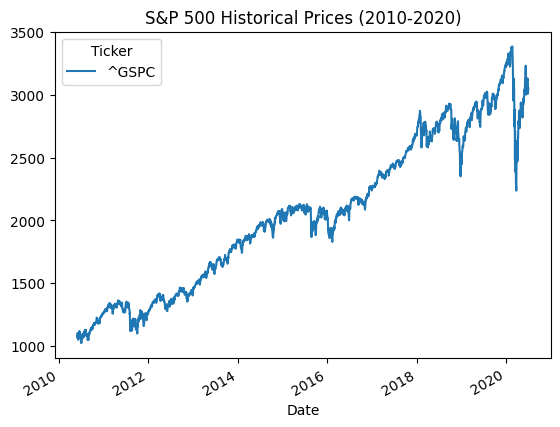

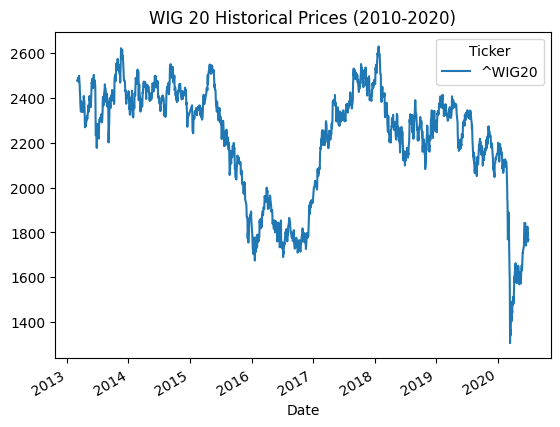

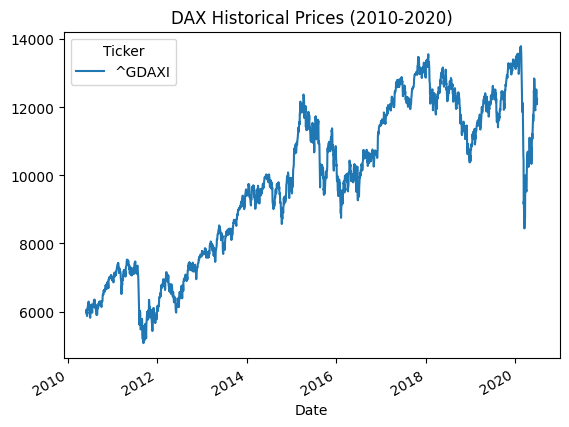

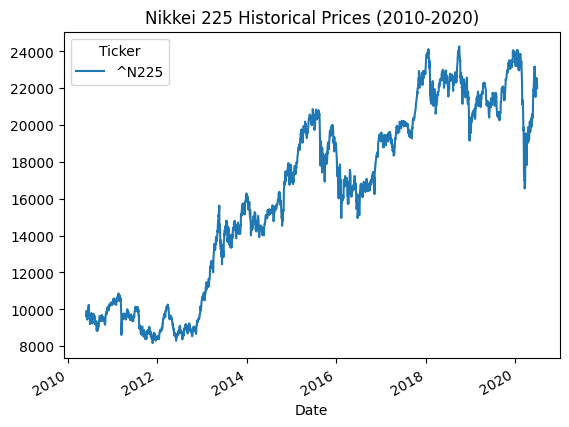

In [14]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


start_date = "2010-06-01"
end_date = "2020-06-30"

# Download data (each index in its own DataFrame)
sp500_data  = yf.download('^GSPC',  start=start_date, end=end_date)
wig20_data  = yf.download('^WIG20', start=start_date, end=end_date)
dax_data    = yf.download('^GDAXI', start=start_date, end=end_date)
nikkei_data = yf.download('^N225',  start=start_date, end=end_date)
# Plot each index
for name, df in {
    "S&P 500": sp500_data,
    "WIG 20": wig20_data,
    "DAX": dax_data,
    "Nikkei 225": nikkei_data,
}.items():
    df["Close"].plot(title=f"{name} Historical Prices (2010–2020)")
    plt.xlabel("Date"); plt.ylabel("Close")
    plt.tight_layout(); plt.show()


In the following we want to analyze the stationarity of the time series, using unit root test like ADP and KPSS.

In [17]:
# === ADF & KPSS for WIG20, S&P500, DAX, Nikkei 225 ===
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

def stationarity_values(series):
    series = series.dropna()
    a_stat, a_p, *_ = adfuller(series, autolag="AIC")
    k_stat, k_p, *_ = kpss(series, regression="c", nlags="auto")
    return a_stat, a_p, k_stat, k_p

results = []
for name, df in {
    "WIG 20": wig20_data,
    "S&P 500": sp500_data,
    "DAX": dax_data,
    "Nikkei 225": nikkei_data,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close"])
    results.append((name,
                    f"{a_stat: .2f}\n({a_p:.2f})",
                    f"{k_stat: .2f}\n({k_p:.2f})"))

table = pd.DataFrame(results, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table.style.set_properties(**{'white-space': 'pre-wrap'}))


# Add comment on results

/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_3634/4093136038.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  k_stat, k_p, *_ = kpss(series, regression="c", nlags="auto")
/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_3634/4093136038.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  k_stat, k_p, *_ = kpss(series, regression="c", nlags="auto")
/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_3634/4093136038.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  k_stat, k_p, *_ = kpss(series, regression="c", nlags="auto")
/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_3634/409

,ADF,KPSS
Stock index,,
WIG 20,-2.03 (0.27),1.05 (0.01)
S&P 500,-0.76 (0.83),8.03 (0.01)
DAX,-1.67 (0.45),7.33 (0.01)
Nikkei 225,-1.20 (0.67),7.32 (0.01)
